Import libraries

In [12]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from dragonnet import Dragonnet
import sys
from pathlib import Path
project_root = Path("/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [13]:
%time train_df = pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/val_men.csv")

CPU times: user 20.6 ms, sys: 8.02 ms, total: 28.6 ms
Wall time: 28.3 ms
CPU times: user 12.3 ms, sys: 1.99 ms, total: 14.3 ms
Wall time: 14.3 ms
CPU times: user 4.26 ms, sys: 5 μs, total: 4.27 ms
Wall time: 4.27 ms


In [14]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
label_feature = ['spend']
treatment_feature = ['treatment']

In [15]:
X_train = train_df[in_features].values.astype(float) # type: ignore
y_train = train_df[label_feature].values.astype(float) # type: ignore
t_train = train_df[treatment_feature].values.astype(float) # type: ignore

X_test = test_df[in_features].values.astype(float) # type: ignore
y_test = test_df[label_feature].values.astype(float) # type: ignore
t_test = test_df[treatment_feature].values.astype(float) # type: ignore

X_val = val_df[in_features].values.astype(float) # type: ignore
y_val = val_df[label_feature].values.astype(float) # type: ignore
t_val = val_df[treatment_feature].values.astype(float) # type: ignore

In [16]:
print('X_train[:10]', X_train[:1].astype(float))

X_train[:10] [[-0.21435131  1.6331766   1.0667411   0.90252386 -1.1010233   1.07039981
   1.00043033  2.70003843 -0.88552759 -0.88616046]]


In [17]:
print('y_train[:10]', y_train[:1].astype(float))

y_train[:10] [[0.]]


In [18]:
# Transform to tensor
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

x_men_train_t = to_tensor(X_train)
x_men_val_t = to_tensor(X_val)
x_men_test_t = to_tensor(X_test)

y_men_train_t = to_tensor(y_train).reshape(-1, 1)
y_men_val_t = to_tensor(y_val).reshape(-1, 1)
y_men_test_t = to_tensor(y_test).reshape(-1, 1)

# t_train/t_val/t_test cũng tương tự
t_men_train_t = to_tensor(t_train.astype(float)).reshape(-1, 1)
t_men_val_t = to_tensor(t_val.astype(float)).reshape(-1, 1)
t_men_test_t = to_tensor(t_test.astype(float)).reshape(-1, 1)

# Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

batch_size = 6400
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory = True)

print("-------------------------------------------------------------")
print("✅ Completed transform to tensor ✅")
print(f"Shape of train: x={x_men_train_t.shape}; y={y_men_train_t.shape}; t={t_men_train_t.shape}")
print(f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print(f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅ Completed transform to tensor ✅
Shape of train: x=torch.Size([25567, 10]); y=torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 10]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 10]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


In [19]:
epochs = 70
lr = 1e-4
wd = 1e-5
early_stop_metric = "qini"
ema = True
ema_alpha = 0.15
patience = 15
shared_dropout = 0
outcome_droupout = 0 
shared_hidden = 200
outcome_hidden = 100
early_stop_start = 0
print (f" epochs = {epochs}")
print (f" learning rate = {lr}")
print (f" weight decay = {wd}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" shared hidden = {shared_hidden}")
print (f" outcome hidden = {outcome_hidden}")
print (f" early stop start = {early_stop_start}")

 epochs = 70
 learning rate = 0.0001
 weight decay = 1e-05
 early stop = qini
 use ema = True
 ema alpha = 0.15
 patience = 15
 shared hidden = 200
 outcome hidden = 100
 early stop start = 0


🔒 Locked Random Seed: 412312
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/70 | Base Loss: 415.6729 | Tarreg Loss: 209.919067 | Total Loss: 625.5920 | Val Loss: 499.6360 | Raw Qini: 0.3918 | EMA Trend: 0.3918 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/70 | Base Loss: 538.3109 | Tarreg Loss: 270.856323 | Total Loss: 809.1672 | Val Loss: 499.5873 | Raw Qini: 0.4253 | EMA Trend: 0.3968 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/70 | Base Loss: 288.8942 | Tarreg Loss: 144.983963 | Total Loss: 433.8782 | Val Loss: 499.5359 | Raw Qini: 0.4769 | EMA Trend: 0.4089 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/70 | Base Loss: 262.8796 | Tarreg Loss: 132.630112 | Total Loss: 395.5098 | Val Loss: 499.4774 | Raw Qini: 0.5556 | EMA Trend: 0.4309 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/70 | Base Loss: 656.7855

/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/Revenue/Dragonnet/dragonnet.py:324: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


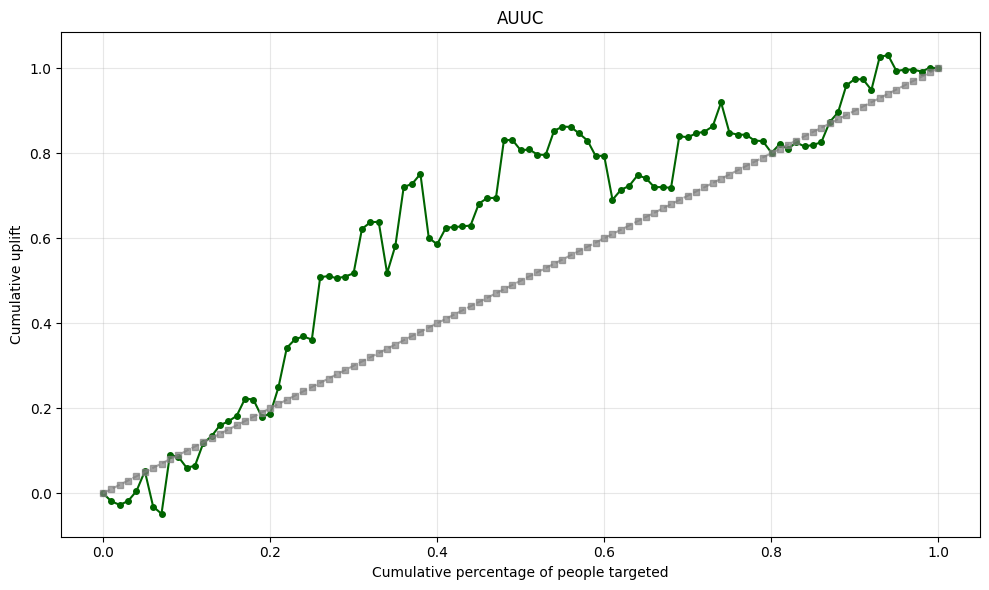

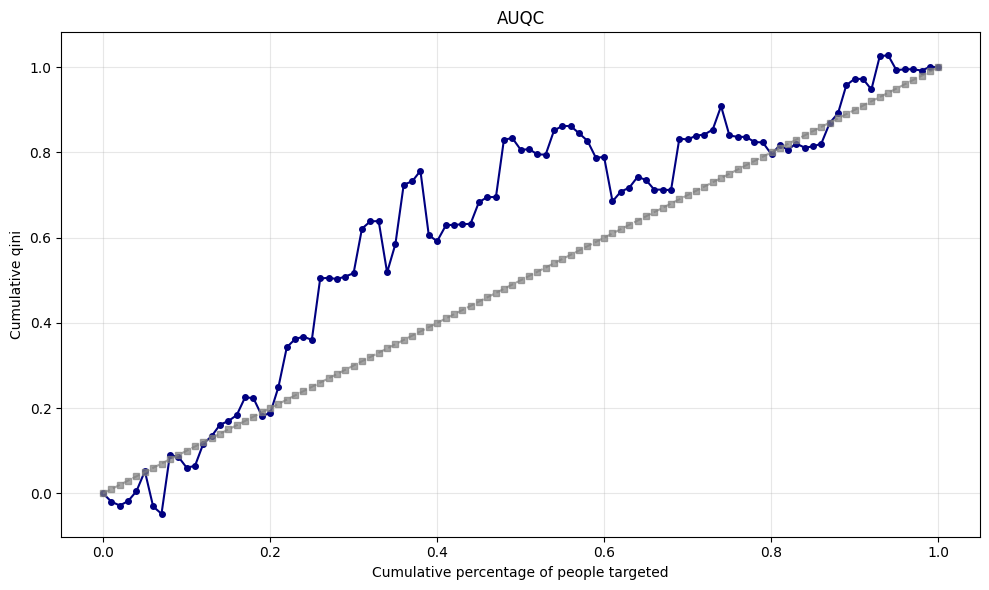

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.617
AUQC: 0.615
Lift: 1.013
KRCC: 0.067
ATE (predicted): 1.5988
ATE (true): 0.5874
ATE error: 1.0114


In [20]:
seed = 412312
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 42
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/70 | Base Loss: 423.6235 | Tarreg Loss: 212.998199 | Total Loss: 636.6217 | Val Loss: 499.1687 | Raw Qini: 0.6260 | EMA Trend: 0.6260 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/70 | Base Loss: 497.9062 | Tarreg Loss: 247.974854 | Total Loss: 745.8811 | Val Loss: 499.1206 | Raw Qini: 0.5783 | EMA Trend: 0.6188 | (patience: 1/15)
Epoch 3/70 | Base Loss: 516.2374 | Tarreg Loss: 257.660828 | Total Loss: 773.8982 | Val Loss: 499.0685 | Raw Qini: 0.5581 | EMA Trend: 0.6097 | (patience: 2/15)
Epoch 4/70 | Base Loss: 349.1582 | Tarreg Loss: 175.276382 | Total Loss: 524.4346 | Val Loss: 499.0121 | Raw Qini: 0.4632 | EMA Trend: 0.5877 | (patience: 3/15)
Epoch 5/70 | Base Loss: 357.6628 | Tarreg Loss: 178.955826 | To

/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/Revenue/Dragonnet/dragonnet.py:324: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


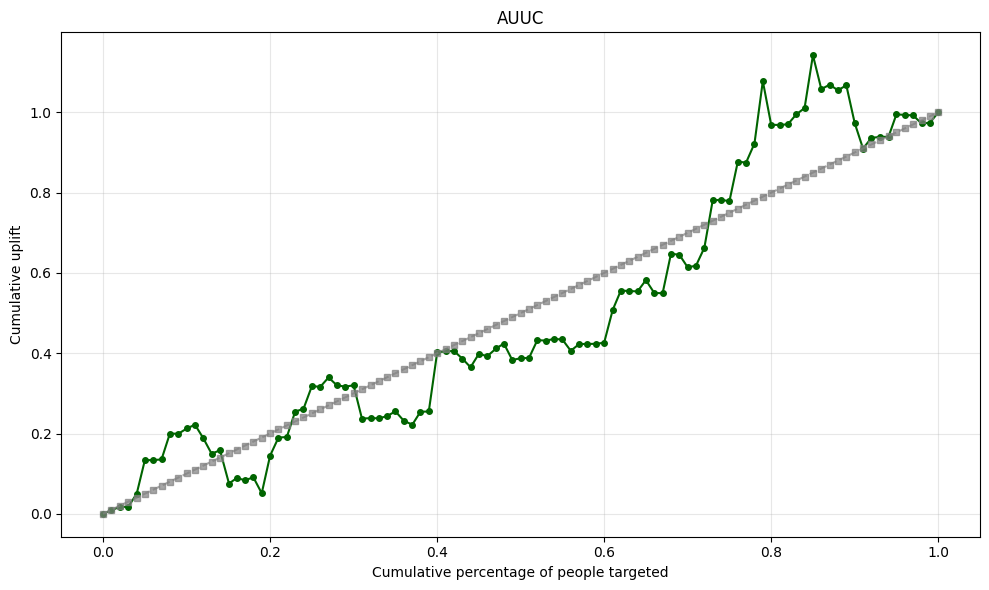

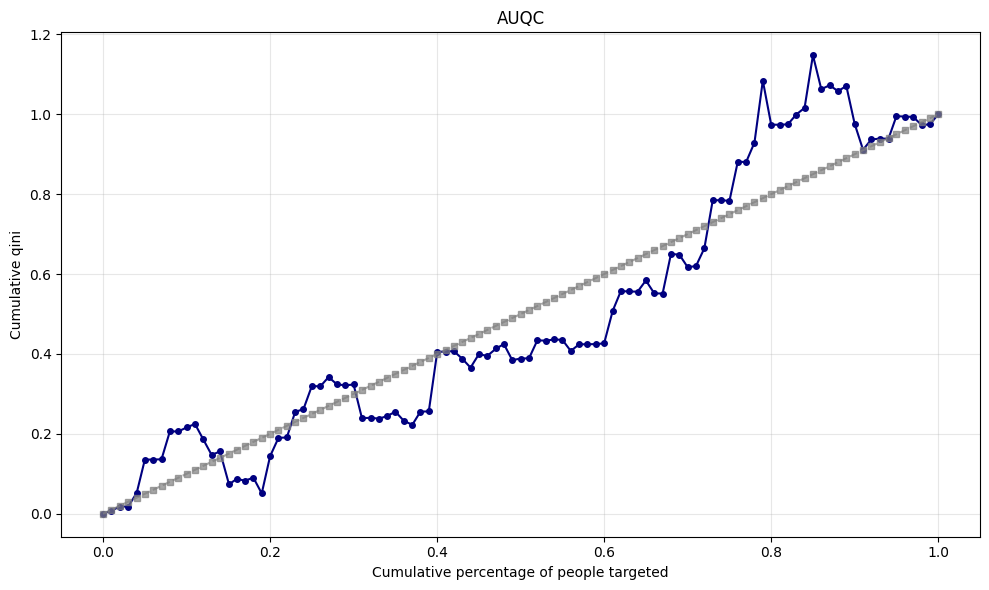

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.495
AUQC: 0.497
Lift: 0.627
KRCC: 0.015
ATE (predicted): 0.0654
ATE (true): 0.5874
ATE error: 0.5220


In [21]:
seed = 42
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 1874
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/70 | Base Loss: 422.1537 | Tarreg Loss: 223.262924 | Total Loss: 645.4166 | Val Loss: 499.4599 | Raw Qini: 0.3184 | EMA Trend: 0.3184 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/70 | Base Loss: 457.9319 | Tarreg Loss: 240.120056 | Total Loss: 698.0519 | Val Loss: 499.4287 | Raw Qini: 0.3580 | EMA Trend: 0.3244 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/70 | Base Loss: 564.1981 | Tarreg Loss: 293.196259 | Total Loss: 857.3943 | Val Loss: 499.3928 | Raw Qini: 0.3983 | EMA Trend: 0.3355 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/70 | Base Loss: 600.3474 | Tarreg Loss: 308.588531 | Total Loss: 908.9359 | Val Loss: 499.3502 | Raw Qini: 0.4302 | EMA Trend: 0.3497 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/70 | Base Loss: 406.6743 |

/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/Revenue/Dragonnet/dragonnet.py:324: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


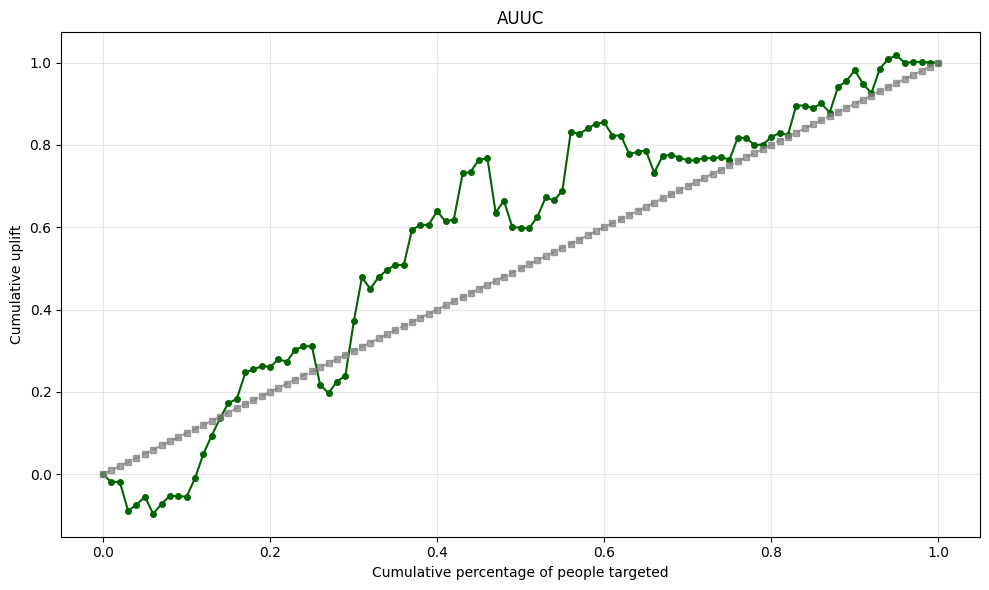

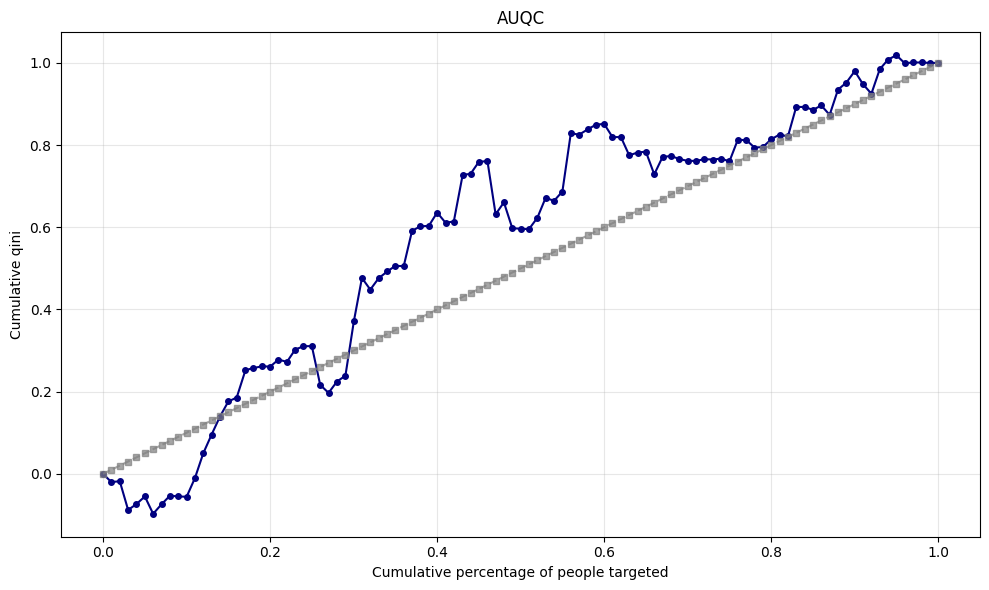

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.574
AUQC: 0.572
Lift: 0.727
KRCC: 0.106
ATE (predicted): 2.7597
ATE (true): 0.5874
ATE error: 2.1723


In [22]:
seed =1874
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 902745
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/70 | Base Loss: 408.9040 | Tarreg Loss: 208.844086 | Total Loss: 617.7481 | Val Loss: 499.2222 | Raw Qini: 0.2930 | EMA Trend: 0.2930 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/70 | Base Loss: 353.6648 | Tarreg Loss: 182.481293 | Total Loss: 536.1461 | Val Loss: 499.1770 | Raw Qini: 0.3212 | EMA Trend: 0.2972 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/70 | Base Loss: 373.3459 | Tarreg Loss: 192.316071 | Total Loss: 565.6620 | Val Loss: 499.1304 | Raw Qini: 0.4246 | EMA Trend: 0.3163 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/70 | Base Loss: 442.2842 | Tarreg Loss: 224.809174 | Total Loss: 667.0934 | Val Loss: 499.0800 | Raw Qini: 0.5311 | EMA Trend: 0.3485 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/70 | Base Loss: 483.2718

/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/Revenue/Dragonnet/dragonnet.py:324: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


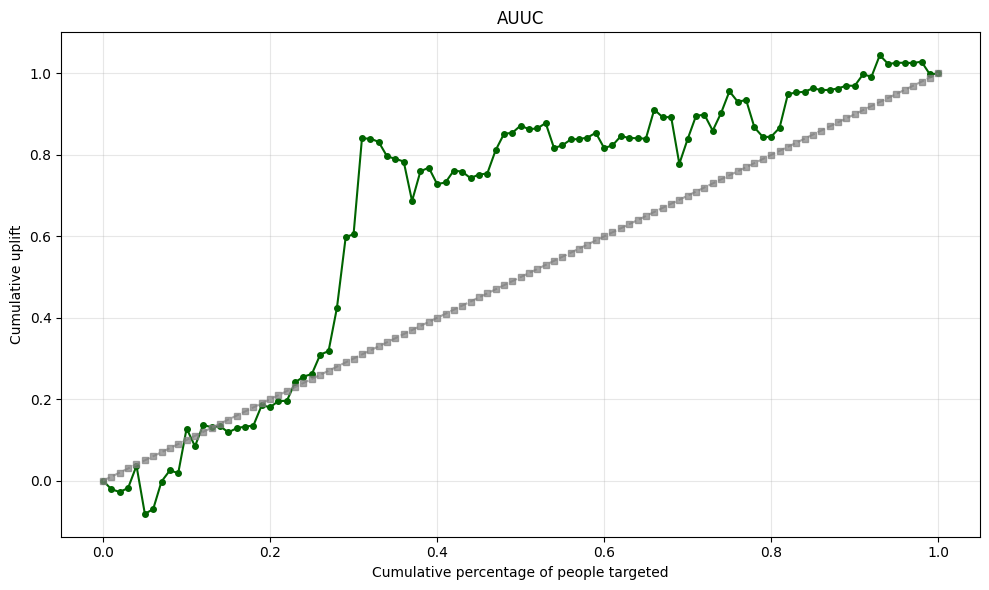

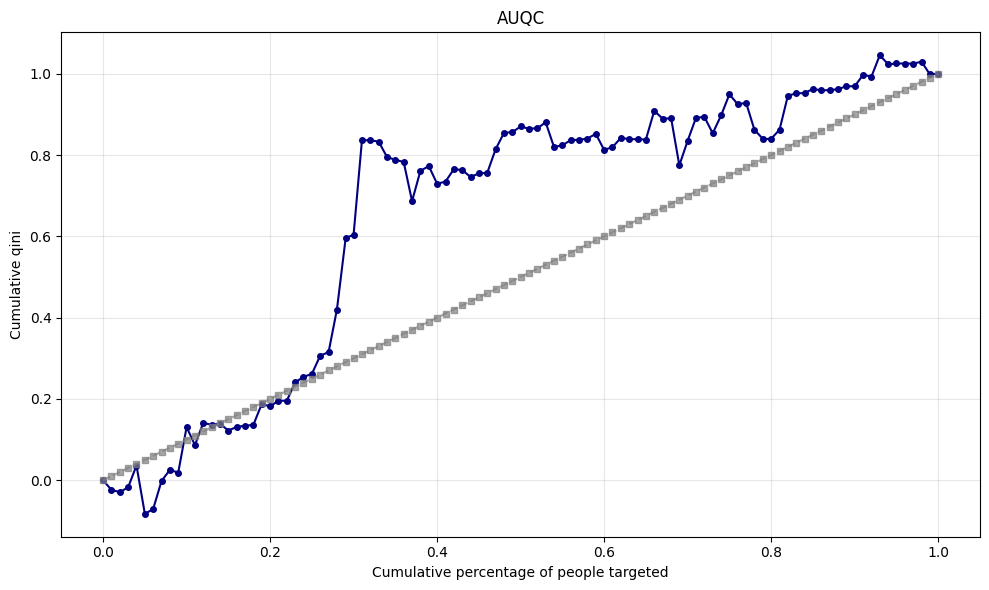

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.655
AUQC: 0.654
Lift: 1.186
KRCC: 0.061
ATE (predicted): 2.0184
ATE (true): 0.5874
ATE error: 1.4309


In [23]:
seed = 902745
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

🔒 Locked Random Seed: 1
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/70 | Base Loss: 440.3964 | Tarreg Loss: 222.007797 | Total Loss: 662.4042 | Val Loss: 499.7763 | Raw Qini: 0.5976 | EMA Trend: 0.5976 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/70 | Base Loss: 336.6787 | Tarreg Loss: 170.958420 | Total Loss: 507.6371 | Val Loss: 499.7171 | Raw Qini: 0.5731 | EMA Trend: 0.5939 | (patience: 1/15)
Epoch 3/70 | Base Loss: 713.7747 | Tarreg Loss: 356.475311 | Total Loss: 1070.2500 | Val Loss: 499.6584 | Raw Qini: 0.5811 | EMA Trend: 0.5920 | (patience: 2/15)
Epoch 4/70 | Base Loss: 553.5407 | Tarreg Loss: 278.807220 | Total Loss: 832.3479 | Val Loss: 499.5951 | Raw Qini: 0.5790 | EMA Trend: 0.5900 | (patience: 3/15)
Epoch 5/70 | Base Loss: 437.8382 | Tarreg Loss: 219.224945 | To

/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/Revenue/Dragonnet/dragonnet.py:324: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


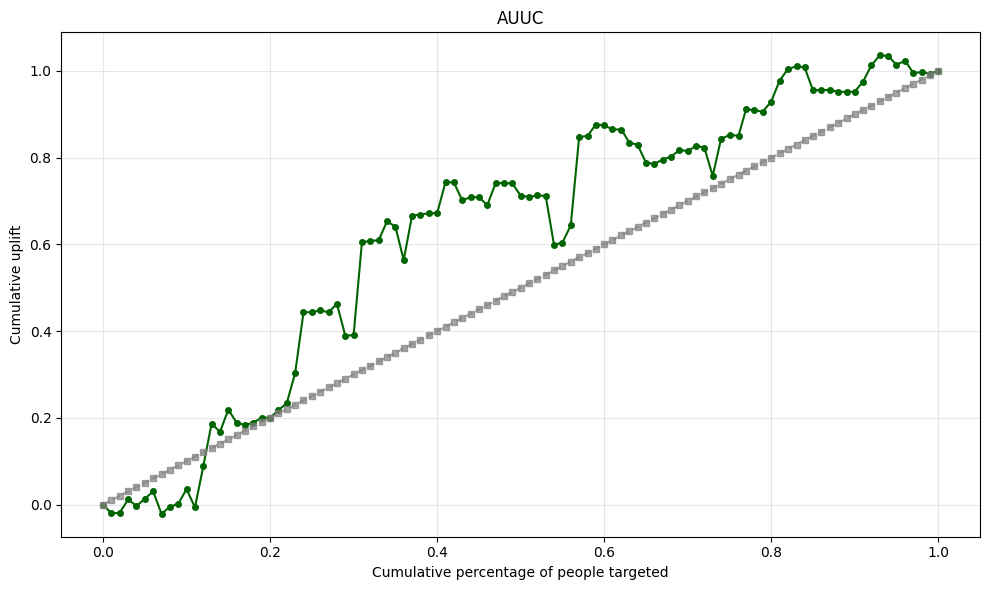

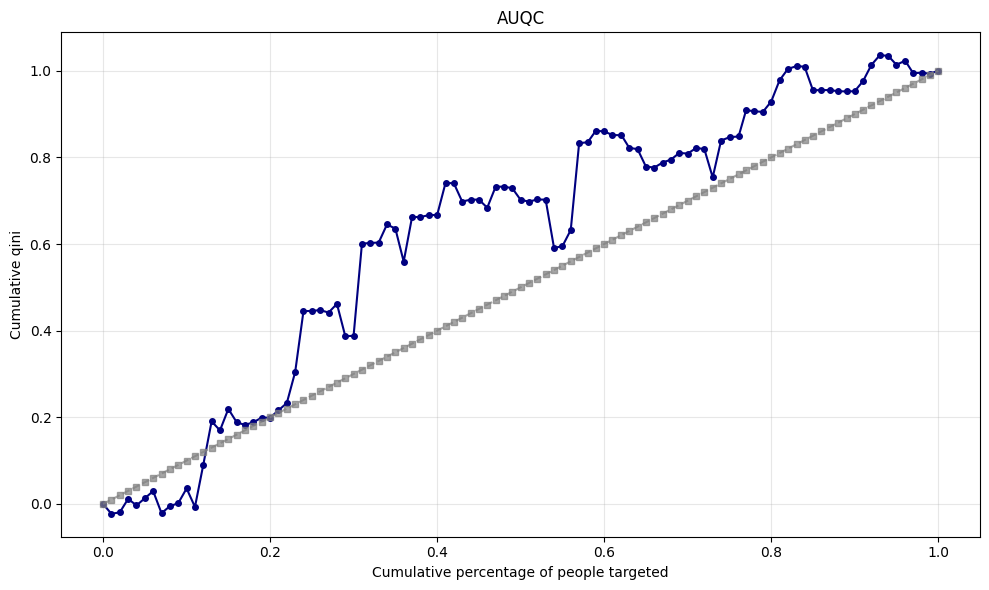

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.626
AUQC: 0.622
Lift: 0.764
KRCC: 0.018
ATE (predicted): 1.3618
ATE (true): 0.5874
ATE error: 0.7744


In [24]:
seed = 1
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")